## 3.2 Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv"

In [3]:
!wget -nc $data -O data_week3.csv #-O with file name is instructing python to save it under that name 

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
df = pd.read_csv("data_week3.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Transposing the columns to have a look at all of them

In [6]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [7]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.select_dtypes(include=['object', 'string']).columns)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [8]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [9]:
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                   str
dtype: object

In [10]:
df.totalcharges


0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: totalcharges, Length: 7043, dtype: str

Convert it into an integer

In [11]:
import traceback

try:
    pd.to_numeric(df.totalcharges)

except Exception as e:
    print(e)
    traceback.print_exc()

Unable to parse string "_" at position 488


Traceback (most recent call last):
  File "pandas/_libs/lib.pyx", line 2478, in pandas._libs.lib.maybe_convert_numeric
ValueError: Unable to parse string "_"

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\PC\AppData\Local\Temp\ipykernel_6676\1359771946.py", line 4, in <module>
    pd.to_numeric(df.totalcharges)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "e:\Data Science\gachau_learning\venv\Lib\site-packages\pandas\core\tools\numeric.py", line 235, in to_numeric
    values, new_mask = lib.maybe_convert_numeric(  # type: ignore[call-overload]
                       ~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        values,
        ^^^^^^^
    ...<6 lines>...
        ),
        ^^
    )
    ^
  File "pandas/_libs/lib.pyx", line 2521, in pandas._libs.lib.maybe_convert_numeric
ValueError: Unable to parse string "_" at position 488


ValueError: Unable to parse string "_"
The error above was because I replaced all spaces with underscores including spaces in the column totalcharges

In [12]:
tc = pd.to_numeric(df.totalcharges, errors='coerce')
df[tc.isnull()]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
488,4472-lvygi,female,0,yes,yes,0,no,no_phone_service,dsl,yes,...,yes,yes,yes,no,two_year,yes,bank_transfer_(automatic),52.55,_,no
753,3115-czmzd,male,0,no,yes,0,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,20.25,_,no
936,5709-lvoeq,female,0,yes,yes,0,yes,no,dsl,yes,...,yes,no,yes,yes,two_year,no,mailed_check,80.85,_,no
1082,4367-nuyao,male,0,yes,yes,0,yes,yes,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,25.75,_,no
1340,1371-dwpaz,female,0,yes,yes,0,no,no_phone_service,dsl,yes,...,yes,yes,yes,no,two_year,no,credit_card_(automatic),56.05,_,no
3331,7644-omvmy,male,0,yes,yes,0,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.85,_,no
3826,3213-vvolg,male,0,yes,yes,0,yes,yes,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,25.35,_,no
4380,2520-sgtta,female,0,yes,yes,0,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,20.00,_,no
5218,2923-arzlg,male,0,yes,yes,0,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,one_year,yes,mailed_check,19.70,_,no
6670,4075-wkniu,female,0,yes,yes,0,yes,yes,dsl,no,...,yes,yes,yes,no,two_year,no,mailed_check,73.35,_,no


In [13]:
df[tc.isnull()][['customerid', 'totalcharges']]

,customerid,totalcharges
488,4472-lvygi,_
753,3115-czmzd,_
936,5709-lvoeq,_
1082,4367-nuyao,_
1340,1371-dwpaz,_
3331,7644-omvmy,_
3826,3213-vvolg,_
4380,2520-sgtta,_
5218,2923-arzlg,_
6670,4075-wkniu,_


In [14]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors = 'coerce')
df.totalcharges = df.totalcharges.fillna(0)

In [15]:
df[tc.isnull()][['customerid', 'totalcharges']]

,customerid,totalcharges
488,4472-lvygi,0.0
753,3115-czmzd,0.0
936,5709-lvoeq,0.0
1082,4367-nuyao,0.0
1340,1371-dwpaz,0.0
3331,7644-omvmy,0.0
3826,3213-vvolg,0.0
4380,2520-sgtta,0.0
5218,2923-arzlg,0.0
6670,4075-wkniu,0.0


### Checking the churn variable

Need to be turned into numbers
1 = Yes
0 = No

In [16]:
df.churn.value_counts()


churn
no     5174
yes    1869
Name: count, dtype: int64

In [17]:
(df.churn == 'yes').astype(int).head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

In [18]:
df['churn'] = (df['churn'] == 'yes').astype(int)
df

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,0
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one_year,no,mailed_check,56.95,1889.50,0
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,1
3,7795-cfocw,male,0,no,no,45,no,no_phone_service,dsl,yes,...,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,0
4,9237-hqitu,female,0,no,no,2,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-resvb,male,0,yes,yes,24,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,yes,mailed_check,84.80,1990.50,0
7039,2234-xaduh,female,0,yes,yes,72,yes,yes,fiber_optic,no,...,yes,no,yes,yes,one_year,yes,credit_card_(automatic),103.20,7362.90,0
7040,4801-jzazl,female,0,yes,yes,11,no,no_phone_service,dsl,yes,...,no,no,no,no,month-to-month,yes,electronic_check,29.60,346.45,0
7041,8361-ltmkd,male,1,yes,no,4,yes,yes,fiber_optic,no,...,no,no,no,no,month-to-month,yes,mailed_check,74.40,306.60,1


In [19]:
df.churn.value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

## 3.3 Setting up the validation framework

- Perform the train/val/test split with Scikit-Learn

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
len(df_full_train), len(df_test)

(5634, 1409)

In [22]:
df_train, df_val = train_test_split(df_full_train, test_size=0.2, random_state=1)
len(df_train), len(df_val), len(df_test)

(4507, 1127, 1409)

df_val has an issue because it is 20% of df_full_train and not 20% of the entire df. To fix this, we need to make df_val 20%/80% * 100 which is 25%

In [23]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [24]:
df_train

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
3897,8015-ihcgw,female,0,yes,yes,72,yes,yes,fiber_optic,yes,...,yes,yes,yes,yes,two_year,yes,electronic_check,115.50,8425.15,0
1980,1960-uycnn,male,0,no,no,10,yes,yes,fiber_optic,no,...,yes,no,no,yes,month-to-month,yes,electronic_check,95.25,1021.55,0
6302,9250-wypll,female,0,no,no,5,yes,yes,fiber_optic,no,...,no,no,no,no,month-to-month,no,electronic_check,75.55,413.65,1
727,6786-obwqr,female,0,yes,yes,5,yes,no,fiber_optic,no,...,no,no,yes,no,month-to-month,yes,electronic_check,80.85,356.10,0
5104,1328-euzhc,female,0,yes,no,18,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,20.10,370.50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3774,1309-xgfsn,male,1,yes,yes,52,yes,yes,dsl,no,...,yes,no,yes,yes,one_year,yes,electronic_check,80.85,4079.55,0
6108,4819-hjpiw,male,0,no,no,18,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,no,mailed_check,25.15,476.80,0
1530,3703-vavcl,male,0,yes,yes,2,yes,no,fiber_optic,no,...,yes,yes,no,yes,month-to-month,no,credit_card_(automatic),90.00,190.05,1
3701,3812-lrzir,female,0,yes,yes,27,yes,yes,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,electronic_check,24.50,761.95,0


Reset index

In [25]:
df_train.reset_index(drop=True)
df_val.reset_index(drop=True)
df_test.reset_index(drop=True)

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,8879-zkjof,female,0,no,no,41,yes,no,dsl,yes,...,yes,yes,yes,yes,one_year,yes,bank_transfer_(automatic),79.85,3320.75,0
1,0201-mibol,female,1,no,no,66,yes,yes,fiber_optic,yes,...,no,no,yes,yes,two_year,yes,bank_transfer_(automatic),102.40,6471.85,0
2,1600-dilpe,female,0,no,no,12,yes,no,dsl,no,...,no,no,no,no,month-to-month,yes,bank_transfer_(automatic),45.00,524.35,0
3,8601-qacrs,female,0,no,no,5,yes,yes,dsl,no,...,no,no,no,no,month-to-month,yes,mailed_check,50.60,249.95,1
4,7919-zodzz,female,0,yes,yes,10,yes,no,dsl,no,...,yes,no,no,yes,one_year,yes,mailed_check,65.90,660.05,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,5130-iekqt,male,1,no,no,25,yes,yes,fiber_optic,no,...,yes,no,yes,yes,month-to-month,no,mailed_check,105.95,2655.25,1
1405,4452-rohmo,female,0,no,no,15,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.60,331.60,0
1406,6164-haqtx,male,0,no,no,71,no,no_phone_service,dsl,yes,...,yes,yes,yes,no,two_year,no,bank_transfer_(automatic),53.95,3888.65,0
1407,3982-dqlus,male,1,yes,yes,65,yes,yes,fiber_optic,yes,...,no,no,no,no,month-to-month,yes,electronic_check,85.75,5688.45,0


In [26]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

We delete this variable to avoid using it accidentally later

Please note the churn variable is not deleted in the df_train_full 

In [27]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

## 3.4 EDA

- Check missing values
- Look at the target variable (churn)
- Look at the numerical and categorical variables

In [28]:
df_full_train = df_full_train.reset_index(drop=True)

In [29]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [30]:
df_full_train['churn'].value_counts(),df_full_train['churn'].value_counts(normalize=True)

(churn
 0    4113
 1    1521
 Name: count, dtype: int64,
 churn
 0    0.730032
 1    0.269968
 Name: proportion, dtype: float64)

The churn rate is 27% which can also be gotten by getting the mean of churn

In [31]:
global_churn = df_full_train['churn'].mean()
round(global_churn, 2)

np.float64(0.27)

In [32]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [33]:
numerical = [
    'tenure',
    'monthlycharges',
    'totalcharges'
]

In [34]:
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
        'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod'] 

In [35]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

## 3.5 Feature Importance: Churn rate and risk ratio
Feature importance analysis(part EDA) - identifying which features affect our target variables

- Churn rate
- Risk Ratio
- Mutual information - later

what is the churn rate per variable

In [36]:
churn_female = df_full_train[df_full_train['gender']== 'female'].churn.mean()
churn_female

np.float64(0.27682403433476394)

In [37]:
churn_male = df_full_train[df_full_train['gender']== 'male'].churn.mean()
churn_male

np.float64(0.2632135306553911)

churn is not dependent on gender

In [38]:
df_full_train['partner'].value_counts()

partner
no     2932
yes    2702
Name: count, dtype: int64

In [39]:
churn_partner = df_full_train[df_full_train['partner']== 'yes'].churn.mean()
churn_partner

np.float64(0.20503330866025166)

In [40]:
global_churn - churn_partner

np.float64(0.06493474245795922)

The difference is positive 6% therefore this group is less likely to churn

In [41]:
churn_no_partner = df_full_train[df_full_train['partner']== 'no'].churn.mean()
churn_no_partner

np.float64(0.3298090040927694)

In [42]:
global_churn - churn_no_partner

np.float64(-0.05984095297455855)

The difference is negative 6% therefore this group is most likely to churn

partner variable seems significant.

Therefore we should consider it when creating our model

### Risk Ratio

Numbers higher than 1 seem more likely to churn

In [43]:
churn_no_partner/global_churn #the churn rate of people without partners is 22% higher than the global churn rate.

np.float64(1.2216593879412643)

In [44]:
churn_partner/global_churn #the churn rate of people with partners is 24.1% lower than the global churn rate.

np.float64(0.7594724924338315)

In [45]:
for c in categorical:
    for category in df_full_train[c].unique():
        churn_rate = df_full_train[df_full_train[c] == category].churn.mean()
        global_churn = df_full_train['churn'].mean()
        difference = churn_rate / global_churn
        if difference > 1:
            print(f"{c}: {category} - Difference: {difference}")

gender: female - Difference: 1.0253955354648652
seniorcitizen: 1 - Difference: 1.5312078272604588
partner: no - Difference: 1.2216593879412643
dependents: no - Difference: 1.162211896354266
phoneservice: yes - Difference: 1.011412080683678
multiplelines: yes - Difference: 1.0769478660297518
internetservice: fiber_optic - Difference: 1.5748953934947045
onlinesecurity: no - Difference: 1.5591515287228357
onlinebackup: no - Difference: 1.4976715099890563
deviceprotection: no - Difference: 1.4663789039974926
techsupport: no - Difference: 1.5517171678486092
streamingtv: no - Difference: 1.269897305927171
streamingtv: yes - Difference: 1.1213277156268175
streamingmovies: yes - Difference: 1.138181818181818
streamingmovies: no - Difference: 1.2553576632967645
contract: month-to-month - Difference: 1.5990819252119808
paperlessbilling: yes - Difference: 1.2525599154742368
paymentmethod: electronic_check - Difference: 1.6886817518293806


SELECT
    
        gender,
        AVG(churn),    
        AVG(churn) - global_churn AS diff,    
        AVG(churn) / global_churn AS risk

FROM
            data

GROUP BY
            gender;

Translate this SQL query to pandas

In [46]:
df_full_train.groupby('gender').churn.mean()

gender
female    0.276824
male      0.263214
Name: churn, dtype: float64

To get a dataframe ,so that we can add the diff and risk columns, instead of a series, we use the aggregate function

In [47]:
df_group = df_full_train.groupby('gender').churn.agg(['mean', 'count'])

Add columns

In [48]:
df_group['diff'] = df_group['mean'] - global_churn
df_group['risk'] = df_group['mean'] / global_churn
df_group

,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980


In [49]:
from IPython.display import display

In [50]:
for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)
    print()
    print()

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




partner


,mean,count,diff,risk
partner,,,,
no,0.329809,2932,0.059841,1.221659
yes,0.205033,2702,-0.064935,0.759472




dependents


,mean,count,diff,risk
dependents,,,,
no,0.313760,3968,0.043792,1.162212
yes,0.165666,1666,-0.104302,0.613651




phoneservice


,mean,count,diff,risk
phoneservice,,,,
no,0.241316,547,-0.028652,0.893870
yes,0.273049,5087,0.003081,1.011412




multiplelines


,mean,count,diff,risk
multiplelines,,,,
no,0.257407,2700,-0.012561,0.953474
no_phone_service,0.241316,547,-0.028652,0.893870
yes,0.290742,2387,0.020773,1.076948




internetservice


,mean,count,diff,risk
internetservice,,,,
dsl,0.192347,1934,-0.077621,0.712482
fiber_optic,0.425171,2479,0.155203,1.574895
no,0.077805,1221,-0.192163,0.288201




onlinesecurity


,mean,count,diff,risk
onlinesecurity,,,,
no,0.420921,2801,0.150953,1.559152
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.153226,1612,-0.116742,0.567570




onlinebackup


,mean,count,diff,risk
onlinebackup,,,,
no,0.404323,2498,0.134355,1.497672
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.217232,1915,-0.052736,0.804660




deviceprotection


,mean,count,diff,risk
deviceprotection,,,,
no,0.395875,2473,0.125907,1.466379
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.230412,1940,-0.039556,0.853480




techsupport


,mean,count,diff,risk
techsupport,,,,
no,0.418914,2781,0.148946,1.551717
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.159926,1632,-0.110042,0.592390




streamingtv


,mean,count,diff,risk
streamingtv,,,,
no,0.342832,2246,0.072864,1.269897
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.302723,2167,0.032755,1.121328




streamingmovies


,mean,count,diff,risk
streamingmovies,,,,
no,0.338906,2213,0.068938,1.255358
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.307273,2200,0.037305,1.138182




contract


,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


## 3.6 Feature Importance : Mutual Information

Mutual information - concept from information theory, it tells us how much we can learn about one variable if we know the value of another

In [51]:
from sklearn.metrics import mutual_info_score

In [52]:
mutual_info_score(df_full_train['churn'], df_full_train['contract']) #Order doesn't matter for mutual information. It is symmetric, meaning that the mutual information between two variables is the same regardless of which variable is considered first.

0.0983203874041556

In [53]:
mutual_info_score(df_full_train['gender'], df_full_train['churn'])

0.0001174846211139946

In [54]:
for c in categorical:
    mi = mutual_info_score(df_full_train['churn'], df_full_train[c])
    print(f"{c}: {mi:.4f}")

gender: 0.0001
seniorcitizen: 0.0094
partner: 0.0100
dependents: 0.0123
phoneservice: 0.0002
multiplelines: 0.0009
internetservice: 0.0559
onlinesecurity: 0.0631
onlinebackup: 0.0469
deviceprotection: 0.0435
techsupport: 0.0610
streamingtv: 0.0319
streamingmovies: 0.0316
contract: 0.0983
paperlessbilling: 0.0176
paymentmethod: 0.0432


In [55]:
def mutual_info_churn_score(series):   
    return mutual_info_score(series, df_full_train['churn'])   

In [56]:
df_full_train[categorical].apply(mutual_info_churn_score).sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

## 3.7 Feature Importance: Correlation

How about numerical columns?

- Correlation coefficient - a way of measuring the degree of dependency between two variables

In [57]:
df_full_train[numerical].corrwith(df_full_train['churn'])

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [58]:
df_full_train[numerical].corrwith(df_full_train['churn']).abs() #.abosolute figures showing order of importance of numerical features. The higher the absolute value, the more important the feature is in predicting churn.

tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

In [59]:
df_full_train[numerical].corrwith(df_full_train['churn'])

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

- When tenure and total charges(the longer they stay with the company) increases, the less likely to churn

- The higher the monthly charges are, the more they are likely to leave

In [60]:
df_full_train[df_full_train.tenure <= 2].churn.mean()

np.float64(0.5953420669577875)

The churn rate of people who have been with the company for less than 2 months is really high

In [61]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()

np.float64(0.3994413407821229)

In [62]:
df_full_train[df_full_train.tenure > 12].churn.mean()

np.float64(0.17634908339788277)

- Between 2 months and 12 months the churn rate is 0.39
- The churn rate beyond 12 months is 0.17

## 3.8 One-hot encoding

- Using Scikit-Learn to encode categorical features

In [63]:
from sklearn.feature_extraction import DictVectorizer

In [64]:
df_full_train[['gender', 'contract']].iloc[:10].to_dict

<bound method DataFrame.to_dict of    gender        contract
0    male        two_year
1  female        one_year
2    male        two_year
3    male        one_year
4    male        one_year
5  female  month-to-month
6    male        two_year
7    male  month-to-month
8    male  month-to-month
9  female  month-to-month>

In [65]:
dicts = df_full_train[['gender', 'contract']].iloc[:10].to_dict(orient='records')
dicts

[{'gender': 'male', 'contract': 'two_year'},
 {'gender': 'female', 'contract': 'one_year'},
 {'gender': 'male', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'one_year'},
 {'gender': 'male', 'contract': 'one_year'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'male', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'}]

In [66]:
dv = DictVectorizer() #takes a dictionary and converts it into a feature matrix. It is used to convert categorical features into numerical features.

Then train it

In [67]:
dv.fit(dicts)

DictVectorizer()

In [68]:
dv.transform(dicts)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 20 stored elements and shape (10, 5)>

It produces a Sparse Matrix which is a special way of encoding data when there are many zeros

In [69]:
dv = DictVectorizer(sparse=False) #Sparse matrix is a matrix that is mostly filled with zeros. It is used to save memory when working with large datasets.

In [70]:
dv.fit(dicts)
dv.transform(dicts)

array([[0., 0., 1., 0., 1.],
       [0., 1., 0., 1., 0.],
       [0., 0., 1., 0., 1.],
       [0., 1., 0., 0., 1.],
       [0., 1., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.]])

Let us take the whole dataset ie df_train and not df_train_full

In [71]:
train_dicts = df_train[categorical + numerical].to_dict(orient='records')
train_dicts[0]

{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'yes',
 'deviceprotection': 'yes',
 'techsupport': 'yes',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'two_year',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 72,
 'monthlycharges': 115.5,
 'totalcharges': 8425.15}

In [72]:
dv = DictVectorizer(sparse=False)
dv.fit(train_dicts)

DictVectorizer(sparse=False)

In [73]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [74]:
X_train = dv.transform(train_dicts)
X_train.shape

(4225, 45)

In [75]:
X_train = dv.fit_transform(train_dicts) #Same output by combining fit and transform into one step. It is used to save time when working with large datasets.    
X_train.shape

(4225, 45)

We do not fit the validation data because we want to use the same features as the training data. We only transform the validation data using the same DictVectorizer that was fitted on the training data.

In [76]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')

In [77]:
X_val = dv.transform(val_dicts) 

## 3.9 Logistic Regression

- Binary Classification
- Linear Vs Logistic Regression


We use sigmoid to transform a score into a probability

In [78]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

Ploting the sigmoid

Get a 100 numbers between -7 to 7 

In [79]:
z = np.linspace(-7, 7, 100)
z

array([-7.        , -6.85858586, -6.71717172, -6.57575758, -6.43434343,
       -6.29292929, -6.15151515, -6.01010101, -5.86868687, -5.72727273,
       -5.58585859, -5.44444444, -5.3030303 , -5.16161616, -5.02020202,
       -4.87878788, -4.73737374, -4.5959596 , -4.45454545, -4.31313131,
       -4.17171717, -4.03030303, -3.88888889, -3.74747475, -3.60606061,
       -3.46464646, -3.32323232, -3.18181818, -3.04040404, -2.8989899 ,
       -2.75757576, -2.61616162, -2.47474747, -2.33333333, -2.19191919,
       -2.05050505, -1.90909091, -1.76767677, -1.62626263, -1.48484848,
       -1.34343434, -1.2020202 , -1.06060606, -0.91919192, -0.77777778,
       -0.63636364, -0.49494949, -0.35353535, -0.21212121, -0.07070707,
        0.07070707,  0.21212121,  0.35353535,  0.49494949,  0.63636364,
        0.77777778,  0.91919192,  1.06060606,  1.2020202 ,  1.34343434,
        1.48484848,  1.62626263,  1.76767677,  1.90909091,  2.05050505,
        2.19191919,  2.33333333,  2.47474747,  2.61616162,  2.75

The sigmoid function is used to convert the output of a linear regression model into a probability. It is used in logistic regression to predict the probability of a binary outcome (zeros and ones).

In [80]:
sigmoid(z) #gets numbers between 0 and 1. 


array([9.11051194e-04, 1.04929612e-03, 1.20849325e-03, 1.39180981e-03,
       1.60288907e-03, 1.84592104e-03, 2.12572334e-03, 2.44783371e-03,
       2.81861552e-03, 3.24537821e-03, 3.73651433e-03, 4.30165529e-03,
       4.95184793e-03, 5.69975424e-03, 6.55987647e-03, 7.54881014e-03,
       8.68552699e-03, 9.99168994e-03, 1.14920016e-02, 1.32145869e-02,
       1.51914098e-02, 1.74587216e-02, 2.00575365e-02, 2.30341287e-02,
       2.64405363e-02, 3.03350596e-02, 3.47827268e-02, 3.98556989e-02,
       4.56335711e-02, 5.22035186e-02, 5.96602230e-02, 6.81055013e-02,
       7.76475461e-02, 8.83996772e-02, 1.00478499e-01, 1.14001359e-01,
       1.29083018e-01, 1.45831484e-01, 1.64342987e-01, 1.84696201e-01,
       2.06945849e-01, 2.31116029e-01, 2.57193653e-01, 2.85122575e-01,
       3.14799023e-01, 3.46069006e-01, 3.78728288e-01, 4.12525370e-01,
       4.47167650e-01, 4.82330593e-01, 5.17669407e-01, 5.52832350e-01,
       5.87474630e-01, 6.21271712e-01, 6.53930994e-01, 6.85200977e-01,
      

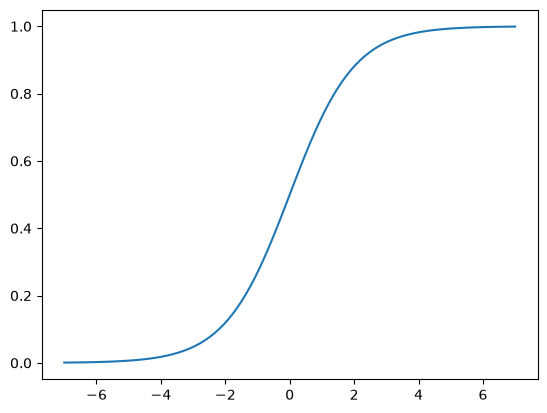

In [81]:
plt.plot(z, sigmoid(z))

In [82]:
def linear_regression(xi, w0, w):
    result = w0
    
    for j in range(len(w)):
        result = result + xi[j] * w[j]
    
    return result

In [83]:
def logistic_regression(xi, w0, w):
    score = w0
    
    for j in range(len(w)):
        score = score + w[j] * xi[j]
        
    result = sigmoid(score)
    return result

## 3.10 Training logistic regression with Scikit-learn

- Train a model with Scikit-Learn
- Apply it to the validation dataset
- Calculate the accuracy

In [84]:
from sklearn.linear_model import LogisticRegression

In [85]:
y_train.mean()

np.float64(0.2686390532544379)

In [86]:
model = LogisticRegression()
model.fit(X_train, y_train)

e:\Data Science\gachau_learning\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

w0

In [87]:
model.intercept_[0]

np.float64(-0.10910575411731115)

These are the weights

In [88]:
model.coef_

array([[ 4.75717837e-01, -1.74974117e-01, -4.08489634e-01,
        -2.99885245e-02, -7.77573894e-02,  6.26589495e-02,
        -8.90715400e-02, -8.13333235e-02, -3.43043508e-02,
        -7.34415631e-02, -3.35503209e-01,  3.16828835e-01,
        -8.90715400e-02,  3.68850280e-03, -2.58257758e-01,
         1.41848117e-01,  8.66372707e-03,  6.25260874e-02,
        -8.90715400e-02, -8.12004613e-02,  2.65657105e-01,
        -8.90715400e-02, -2.84331479e-01, -2.31072067e-01,
         1.23326153e-01, -1.66360757e-01,  5.86148436e-02,
        -8.70789120e-02, -3.19911720e-02,  7.00844586e-02,
        -5.87602885e-02,  1.41848117e-01, -2.49594031e-01,
         2.15655184e-01, -1.20527699e-01, -8.90715400e-02,
         1.01853325e-01, -7.09790548e-02, -8.90715400e-02,
         5.23046809e-02,  2.13260458e-01, -8.90715400e-02,
        -2.31934832e-01, -7.04966672e-02,  3.83087375e-04]])

In [89]:
model.predict(X_train)

array([0, 1, 1, ..., 1, 0, 1], shape=(4225,))

Hard Prediction because we already know the labels Note it only predicts 1s and 0s

In [90]:
model.predict_proba(X_train)

array([[0.90452492, 0.09547508],
       [0.32058285, 0.67941715],
       [0.36630247, 0.63369753],
       ...,
       [0.46766799, 0.53233201],
       [0.95761329, 0.04238671],
       [0.3012034 , 0.6987966 ]], shape=(4225, 2))

These are soft predictions because they are not 1s or 0s

2 dimension matrix with two columns
- First column is probability of it being negative
- Second column is probability of it being positive - the probability of churning

We take the second column

In [91]:
model.predict_proba(X_train)[:,1]

array([0.09547508, 0.67941715, 0.63369753, ..., 0.53233201, 0.04238671,
       0.6987966 ], shape=(4225,))

Let's use the validation data set

In [92]:
y_pred = model.predict_proba(X_val)[:,1]
y_pred

array([0.00896799, 0.20454216, 0.21215178, ..., 0.1363222 , 0.79995367,
       0.83758207], shape=(1409,))

In [93]:
churn_decision = (y_pred >= 0.5)
churn_decision

array([False, False, False, ..., False,  True,  True], shape=(1409,))

Who are the people we should send promotional emails/messages? Who do we think will churn?

In [94]:
df_val[churn_decision].customerid

2504    8433-wxgna
4597    3440-jpscl
2343    2637-fkfsy
5591    7228-omtpn
4482    6711-fldfb
           ...    
2611    5976-jcjrh
4211    2034-cgrhz
3999    5276-kqwhg
6240    6521-yytyi
5282    3049-solay
Name: customerid, Length: 312, dtype: str

In [95]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [96]:
y_val

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

How many match?

In [97]:
y_val == churn_decision


array([ True,  True,  True, ...,  True,  True,  True], shape=(1409,))

In [98]:
(y_val == churn_decision).mean()


np.float64(0.8026969481902059)

80% of our predictions match

What does it look like in a dataframe

In [99]:
df_pred = pd.DataFrame()
df_pred['churn_probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val

In [100]:
df_pred

,churn_probability,prediction,actual
0,0.008968,0,0
1,0.204542,0,0
2,0.212152,0,0
3,0.543024,1,1
4,0.213658,0,0
...,...,...,...
1404,0.313711,0,0
1405,0.039280,0,1
1406,0.136322,0,0
1407,0.799954,1,1


In [101]:
df_pred['correct'] = df_pred['prediction'] == df_pred['actual']

In [102]:
df_pred

,churn_probability,prediction,actual,correct
0,0.008968,0,0,True
1,0.204542,0,0,True
2,0.212152,0,0,True
3,0.543024,1,1,True
4,0.213658,0,0,True
...,...,...,...,...
1404,0.313711,0,0,True
1405,0.039280,0,1,False
1406,0.136322,0,0,True
1407,0.799954,1,1,True


## 3.11 Model Interpretation

- Look at the coefficients
- Train a smaller model with fewer features

In [103]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [104]:
model.coef_[0].round(3)

array([ 0.476, -0.175, -0.408, -0.03 , -0.078,  0.063, -0.089, -0.081,
       -0.034, -0.073, -0.336,  0.317, -0.089,  0.004, -0.258,  0.142,
        0.009,  0.063, -0.089, -0.081,  0.266, -0.089, -0.284, -0.231,
        0.123, -0.166,  0.059, -0.087, -0.032,  0.07 , -0.059,  0.142,
       -0.25 ,  0.216, -0.121, -0.089,  0.102, -0.071, -0.089,  0.052,
        0.213, -0.089, -0.232, -0.07 ,  0.   ])

In [105]:
a=[1,2,3,4]
b='abcd'

print(list(zip(b,a)))

[('a', 1), ('b', 2), ('c', 3), ('d', 4)]


In [106]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.476),
 'contract=one_year': np.float64(-0.175),
 'contract=two_year': np.float64(-0.408),
 'dependents=no': np.float64(-0.03),
 'dependents=yes': np.float64(-0.078),
 'deviceprotection=no': np.float64(0.063),
 'deviceprotection=no_internet_service': np.float64(-0.089),
 'deviceprotection=yes': np.float64(-0.081),
 'gender=female': np.float64(-0.034),
 'gender=male': np.float64(-0.073),
 'internetservice=dsl': np.float64(-0.336),
 'internetservice=fiber_optic': np.float64(0.317),
 'internetservice=no': np.float64(-0.089),
 'monthlycharges': np.float64(0.004),
 'multiplelines=no': np.float64(-0.258),
 'multiplelines=no_phone_service': np.float64(0.142),
 'multiplelines=yes': np.float64(0.009),
 'onlinebackup=no': np.float64(0.063),
 'onlinebackup=no_internet_service': np.float64(-0.089),
 'onlinebackup=yes': np.float64(-0.081),
 'onlinesecurity=no': np.float64(0.266),
 'onlinesecurity=no_internet_service': np.float64(-0.089),
 'onlinesecurity=yes'

In [107]:
small = ['contract', 'tenure', 'monthlycharges']

In [108]:
df_train[small].iloc[:10].to_dict(orient='records')

[{'contract': 'two_year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'two_year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'two_year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'month-to-month', 'tenure': 6, 'monthlycharges': 109.9}]

In [109]:
dict_train_small = df_train[small].to_dict(orient='records')
dict_val_small = df_val[small].to_dict(orient='records')

In [110]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dict_train_small)

DictVectorizer(sparse=False)

In [111]:
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [112]:
X_train_small = dv_small.transform(dict_train_small)

In [113]:
model_small = LogisticRegression()
model_small.fit(X_train_small, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [114]:
w0 = model_small.intercept_[0]
w0.round(3)

np.float64(-2.478)

In [115]:
w = model_small.coef_[0]
w.round(3)

array([ 0.971, -0.024, -0.948,  0.027, -0.036])

In [116]:
dict(zip(dv_small.get_feature_names_out(), w.round(3))) #the weights 

{'contract=month-to-month': np.float64(0.971),
 'contract=one_year': np.float64(-0.024),
 'contract=two_year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

Example

Customer A - monthly contract, 60 usd / month, 1 month with us

Customer B - two_year contract, 30 usd / month, 24 months with us

Due to one hot encoding, the variables in contract that are needed turn hot ie become 1

In [117]:
#Customer A
A = -2.47 + ((1* 0.97) + (0 * (-0.024)) + (0 * (-0.948))) + 60*0.027 + 1 * (-0.036)
A, sigmoid(A)

(0.08399999999999966, np.float64(0.5209876607065322))

Customer A probability of churn is 42% which means the customer is going to churn

In [118]:
#Customer B
B = -2.48 + ((0 * 0.97) + (0 * (-0.024)) + (1 * (-0.948))) + 30*0.027 + 24 * (-0.036)
B, sigmoid(B)

(-3.4819999999999998, np.float64(0.02982874736022579))

The probabily of churn is 30% (which is below 0.5 or 50%) and therefore this customer is not going to churn

## 3.12 Using the Model

Training the model using the full train dataset

Steps 
- Turn the dataset to dictionaries
- Get the feature matrix
- Train the model on these feature matrix
- Repeat for the test dataset
- Get predictions
- Check accuracy

In [119]:
dict_full_train = df_full_train[categorical + numerical].to_dict(orient='records')

In [120]:
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dict_full_train)
X_full_train

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        1.20000e+01, 2.58350e+02],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        4.20000e+01, 3.16055e+03],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.10000e+01, 4.68175e+03],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.80000e+01, 2.97950e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.00000e+00, 1.14100e+02],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        1.60000e+01, 1.11485e+03]], shape=(5634, 45))

In [121]:
y_full_train = df_full_train.churn.values

In [122]:
model = LogisticRegression()
model.fit(X_full_train, y_full_train)

e:\Data Science\gachau_learning\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [123]:
dict_test = df_test[categorical + numerical].to_dict(orient='records')
X_test = dv.transform(dict_test)

In [124]:
y_pred = model.predict_proba(X_test)[:,1]

In [125]:
churn_decision = y_pred >= 0.5

In [126]:
(churn_decision == y_test).mean()

np.float64(0.8140525195173882)